Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


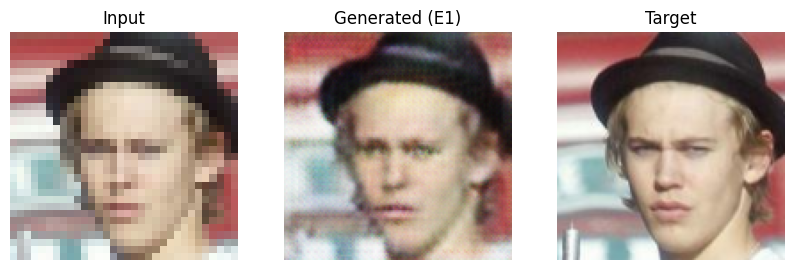

E1 | Time: 177.6s | D_L: 1.3693 | G_L: 1.2996 | PSNR: 24.14dB


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
#standard libraries

import os
import time # to show traiuning time of each epoch
import glob #library to find requested files like .jpg
import pandas as pd #saving history of G_L, D_L, and PSNR
from google.colab import drive #to connect with google drive

#path to save files like images and generator weights
drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/PROJEKT_GAN_SR'
os.makedirs(PROJECT_PATH, exist_ok=True)
#parameters
BATCH_SIZE = 32
EPOCHS = 50
STEPS_PER_EPOCH = 1000
#if google collab doesnt see celeba, it download this
if not os.path.exists('celeba_data'):
    os.system('wget -q https://s3-us-west-1.amazonaws.com/udacity-dlnfd/datasets/celeba.zip')
    os.system('unzip -q celeba.zip -d celeba_data')
#searching for .jpg files
all_files = glob.glob('celeba_data/**/*.jpg', recursive=True) #folders in folders)

#loading and preprocesing data - RGB, croping, resizing, and normalizing for tahn function [-1,1] in "return"
def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize_with_crop_or_pad(img, 160, 160)
    hr = tf.image.resize(img, [128, 128])
    lr = tf.image.resize(hr, [32, 32])
    return (lr - 127.5) / 127.5, (hr - 127.5) / 127.5
#shufling 1000 images and grouping in batches
train_dataset = tf.data.Dataset.from_tensor_slices(all_files)
#required, because first half are men and second women
train_dataset = train_dataset.shuffle(1000).map(load_and_preprocess).batch(BATCH_SIZE)

#generator model
def make_generator_model():
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(64, (3, 3), padding='same', input_shape=[32, 32, 3]))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    #residual blocks to learn complicated textures
    for _ in range(4):
        model.add(layers.Conv2D(64, (3, 3), padding='same'))
        model.add(layers.BatchNormalization())
        model.add(layers.ReLU())
    #first upsampling (scaling x2) 32x32->64x64
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    #second upsampling (scaling again x2) 64x64->128x128
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())
    #activation function tanh (normalization [-1,1] and RGB channel (3)
    model.add(layers.Conv2D(3, (3, 3), padding='same', activation='tanh'))
    return model

def make_discriminator_model():
    model = tf.keras.Sequential()
    #first downsampling recieved image x2 128x128->64x64
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[128, 128, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    #second downsampling x2 64x64->32x32
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    #flattening for dense layer
    model.add(layers.Flatten())
    #recieving one number from 0 to 1, 0=fake, 1=real, 0.5= its not sure
    model.add(layers.Dense(1, activation='sigmoid'))
    return model
#inicialization of models
generator = make_generator_model()
discriminator = make_discriminator_model()

#Adam optimalizator and learning rate, bigger for generator, because discriminator would make him panic too fast
generator_optimizer = tf.keras.optimizers.Adam(2e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-5)
cross_entropy = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()


@tf.function
def train_step(lr_images, hr_images):
    #calculating gradient
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        #generator training with low_res images
        generated_images = generator(lr_images, training=True)
        #discriminator training with high_res images from dataset
        real_output = discriminator(hr_images, training=True)
        #discriminator training with high_res images from dataset
        fake_output = discriminator(generated_images, training=True)
        #loss functions
        #discriminator wants real_output = 1, and fake_output=0
        d_loss = cross_entropy(tf.ones_like(real_output) * 0.9, real_output) + \
                 cross_entropy(tf.zeros_like(fake_output), fake_output)
        #gan loss (details)
        g_gan_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        #mse (colors and form)
        g_pixel_loss = mse(hr_images, generated_images)
        #total loss
        g_loss = (20 * g_pixel_loss) + g_gan_loss
    #gradients calculation
    grads_g = gen_tape.gradient(g_loss, generator.trainable_variables)
    grads_d = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    #changes aplication
    generator_optimizer.apply_gradients(zip(grads_g, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(grads_d, discriminator.trainable_variables))
    return d_loss, g_loss

def train(dataset, epochs):
    #for csv file
    history = {
        'epoch': [],
        'd_loss': [],
        'g_loss': [],
        'psnr': []
    }
    #informations for each epoch
    for epoch in range(epochs):
        start = time.time()
        epoch_d_loss = []
        epoch_g_loss = []

        for lr_batch, hr_batch in dataset.take(STEPS_PER_EPOCH):
            d_l, g_l = train_step(lr_batch, hr_batch)
            epoch_d_loss.append(d_l)
            epoch_g_loss.append(g_l)


        test_lr, test_hr = next(iter(dataset.take(1)))
        fake = generator(test_lr, training=False)
        #PSNR
        current_psnr = tf.image.psnr((fake + 1) / 2, (test_hr + 1) / 2, max_val=1.0)
        avg_psnr = np.mean(current_psnr)

        #saving info of epoch number, d_loss, g_loss, and psnr
        history['epoch'].append(epoch + 1)
        history['d_loss'].append(np.mean(epoch_d_loss))
        history['g_loss'].append(np.mean(epoch_g_loss))
        history['psnr'].append(avg_psnr)

        #saving "3"photos
        plot_and_save_samples(test_lr, fake, test_hr, epoch + 1)


        plot_training_graphs(history)

        #saving info to csv
        pd.DataFrame(history).to_csv(f"{PROJECT_PATH}/training_history.csv", index=False)
        #its for each epoch, to reduce loss of collab session, and for more informations
        if (epoch + 1) % 1 == 0:
            generator.save(f"{PROJECT_PATH}/generator_epoch_{epoch+1}.keras")
        #same thing, but in collab
        print(f'E{epoch+1} | Time: {time.time()-start:.1f}s | D_L: {history["d_loss"][-1]:.4f} | G_L: {history["g_loss"][-1]:.4f} | PSNR: {avg_psnr:.2f}dB')

#visualisation of samples "3"
def plot_and_save_samples(lr, fake, hr, epoch):
    plt.figure(figsize=(10, 4))
    #first batch's image
    imgs = [lr[0], fake[0], hr[0]]
    titles = ["Input", f"Generated (E{epoch})", "Target"]
    #bcs "3"
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow((imgs[i] + 1) / 2)
        plt.title(titles[i])
        plt.axis('off')
    #saving to disc
    plt.savefig(f"{PROJECT_PATH}/sample_epoch_{epoch}.png")
    plt.show()

#PSNR and loss graph
def plot_training_graphs(history):
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.plot(history['epoch'], history['d_loss'], label='Disc Loss', color='red', linestyle='--')
    ax1.plot(history['epoch'], history['g_loss'], label='Gen Loss', color='blue')
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.set_ylabel('PSNR (dB)')
    ax2.plot(history['epoch'], history['psnr'], label='PSNR', color='green', marker='o')
    ax2.legend(loc='upper right')

    plt.title('Training Process: Losses and PSNR')
    plt.savefig(f"{PROJECT_PATH}/training_stats.png")
    plt.close()

#START OF CODE
train(train_dataset, EPOCHS)

Próba załadowania modelu: /content/drive/MyDrive/PROJEKT_GAN_SR/generator_epoch_33.keras


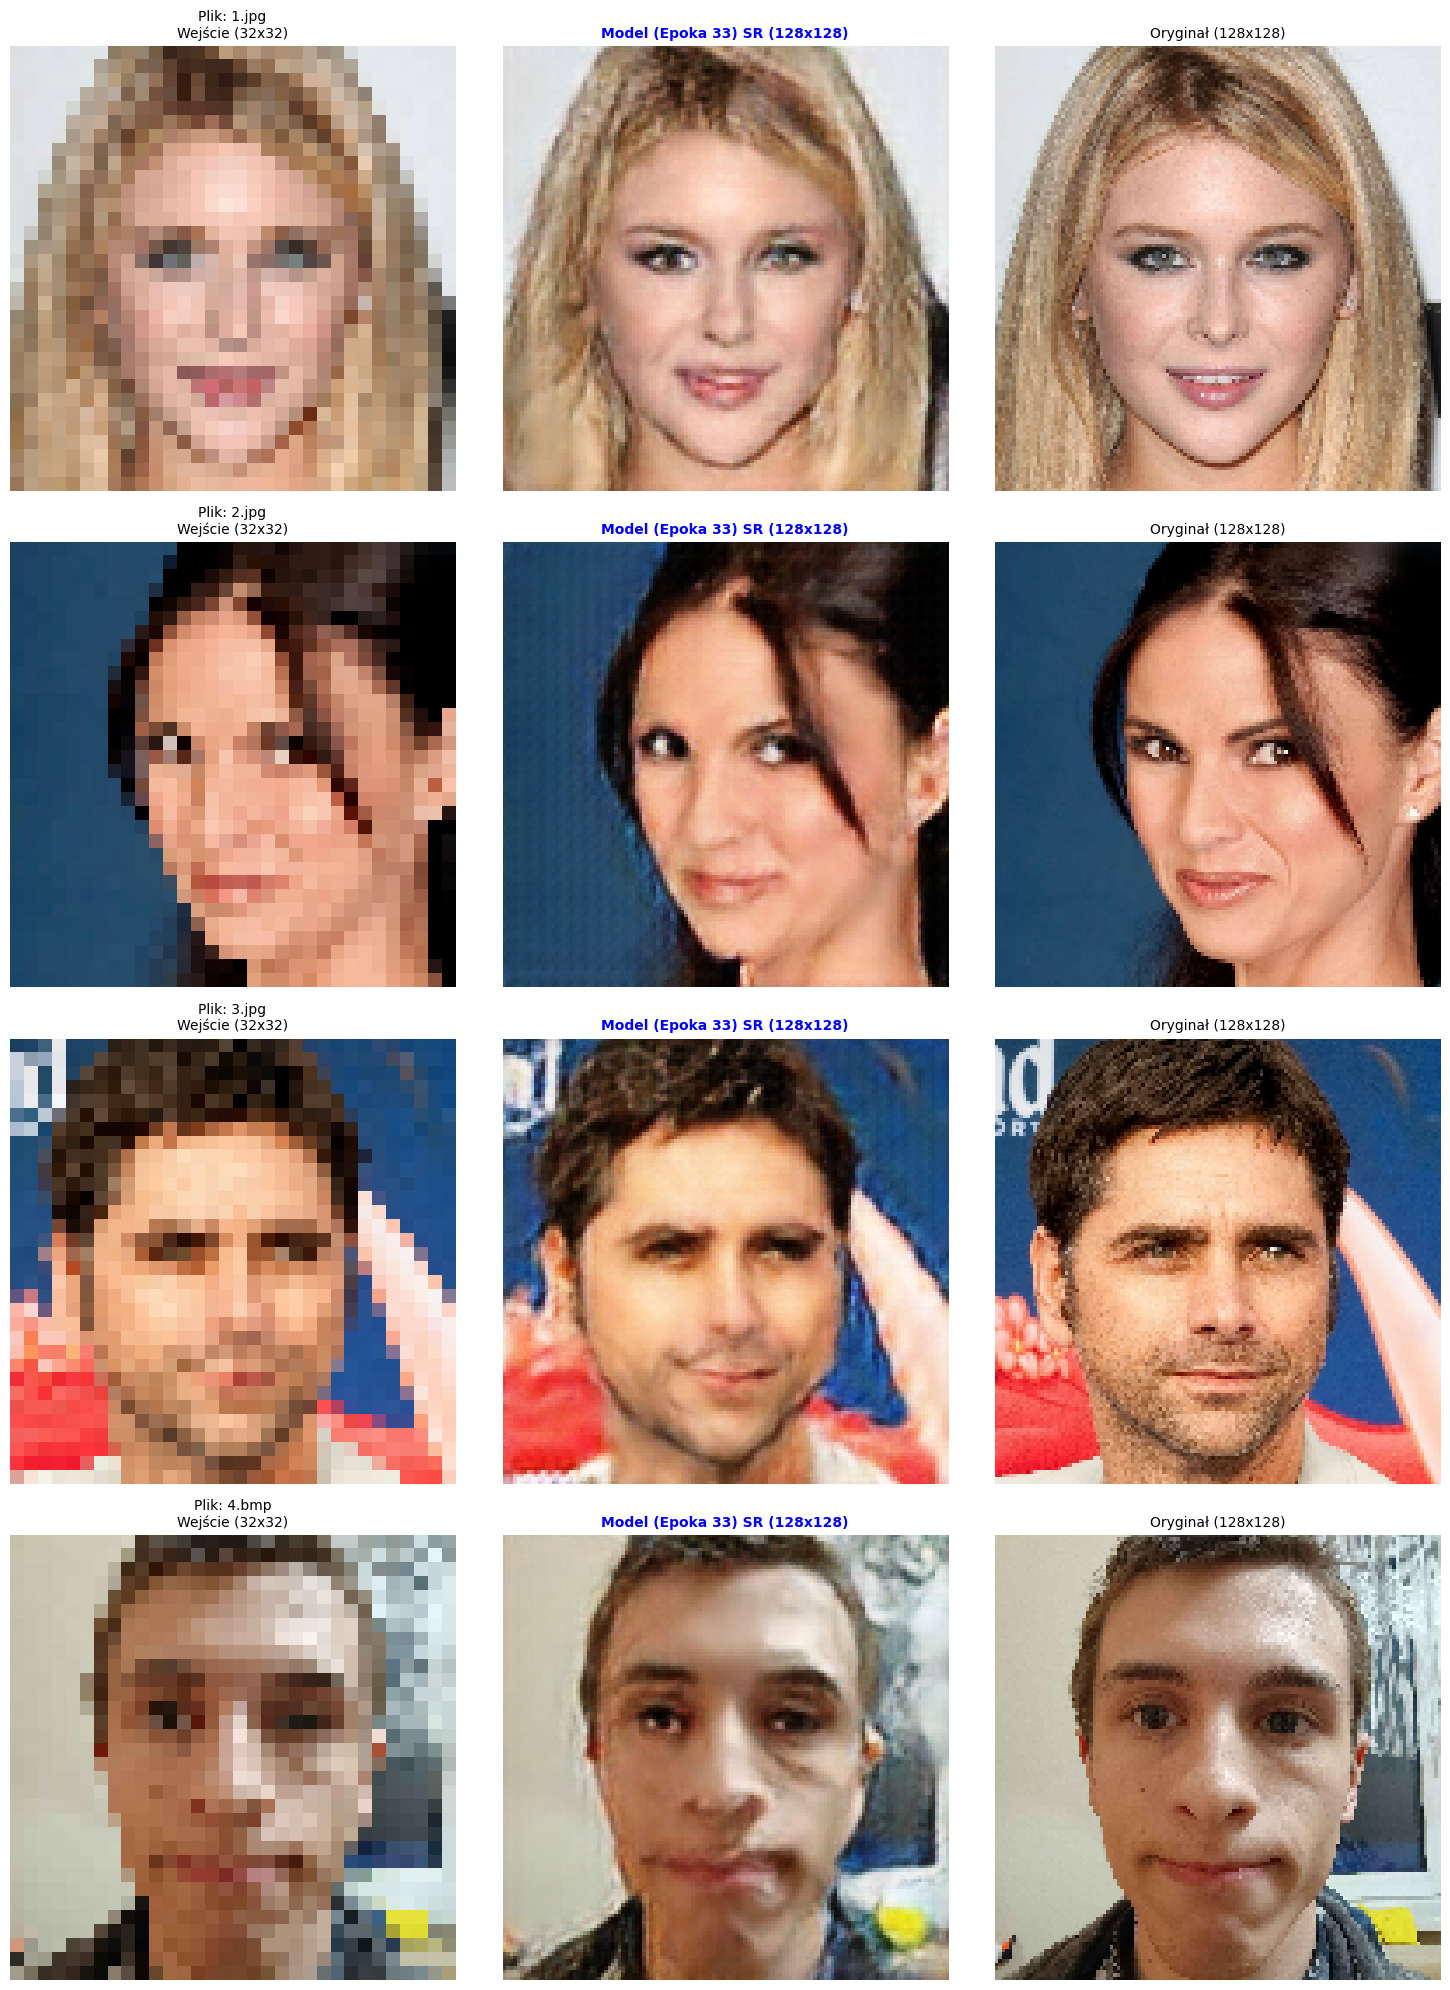

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import os

#last model training path
MODEL_PATH = '/content/drive/MyDrive/PROJEKT_GAN_SR/generator_epoch_33.keras'
#loading
print(f"Próba załadowania modelu: {MODEL_PATH}")
if os.path.exists(MODEL_PATH):
    generator = tf.keras.models.load_model(MODEL_PATH)

image_files = ['1.jpg', '2.jpg', '3.jpg', '4.bmp']
def process_and_compare(filenames):
    plt.figure(figsize=(15, 5 * len(filenames)))

    for i, fname in enumerate(filenames):

        img_raw = tf.io.read_file(fname)

        try:
            img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
        except:
            img = tf.image.decode_jpeg(img_raw, channels=3)

        img = tf.cast(img, tf.float32)

        shape = tf.shape(img)
        min_dim = tf.minimum(shape[0], shape[1])
        img_cropped = tf.image.resize_with_crop_or_pad(img, min_dim, min_dim)
        #resizing
        hr_img = tf.image.resize(img_cropped, [128, 128], method='bicubic')
        lr_img = tf.image.resize(hr_img, [32, 32], method='bicubic')
        #normalization
        lr_input = (lr_img - 127.5) / 127.5
        lr_batch = tf.expand_dims(lr_input, 0)
        fake_output = generator(lr_batch, training=False)[0]
        #plotting
        plt.subplot(len(filenames), 3, i*3 + 1)
        plt.title(f"Plik: {fname}\nWejście (32x32)", fontsize=10)
        plt.imshow(tf.clip_by_value(lr_img / 255.0, 0, 1), interpolation='nearest')
        plt.axis('off')

        plt.subplot(len(filenames), 3, i*3 + 2)
        plt.title(f"Model (Epoka 33) SR (128x128)", fontsize=10, color='blue', fontweight='bold')
        plt.imshow(tf.clip_by_value((fake_output + 1) / 2, 0, 1))
        plt.axis('off')

        plt.subplot(len(filenames), 3, i*3 + 3)
        plt.title(f"Oryginał (128x128)", fontsize=10)
        plt.imshow(tf.clip_by_value(hr_img / 255.0, 0, 1))
        plt.axis('off')

    plt.tight_layout()
    plt.show()

#start
process_and_compare(image_files)